# Practice 3: Customer Clustering - Bước 7.1: Phân tích chân dung khách hàng từ cụm KMeans

---

## 1. Import các thư viện và tải dữ liệu

Chúng ta tải dữ liệu gốc đã làm sạch `Train_cleaned.csv` và nhãn phân cụm đại diện KMeans.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# 1. Tải dữ liệu gốc sạch
df_raw = pd.read_csv('../data/processed/Train_cleaned.csv')

# 2. Tái tạo bộ chỉ số phân tách tập Train deterministically để ghép cặp chính xác
np.random.seed(42)
n_samples = len(df_raw)
n_val = int(n_samples * 0.2)
shuffled_indices = np.random.permutation(n_samples)
train_indices = shuffled_indices[n_val:]

# Trích xuất tập Train thô
df_train = df_raw.iloc[train_indices].copy()

# 3. Ghép nhãn KMeans
kmeans_labels = pd.read_csv('../data/processed_features/kmeans_labels_sklearn.csv')
df_train['Cluster'] = kmeans_labels['KMeans_Label'].values

print(f'Kích thước tập Train thô được ghép nhãn: {df_train.shape}')
print('Số lượng mẫu trong từng cụm KMeans:')
print(df_train['Cluster'].value_counts())

Kích thước tập Train thô được ghép nhãn: (6455, 12)
Số lượng mẫu trong từng cụm KMeans:
Cluster
0    2641
2    2266
1    1548
Name: count, dtype: int64


## 2. Thống kê đặc trưng số học theo cụm

Khảo sát các biến `Age`, `Work_Experience`, và `Family_Size`.

Age        Work_Experience        Family_Size       
              mean median            mean median        mean median
Cluster                                                            
0        32.425218   30.0        2.847028    1.0    2.997349    3.0
1        51.156331   49.0        2.434755    1.0    2.715116    2.0
2        51.335393   50.0        2.109885    1.0    2.808473    2.0

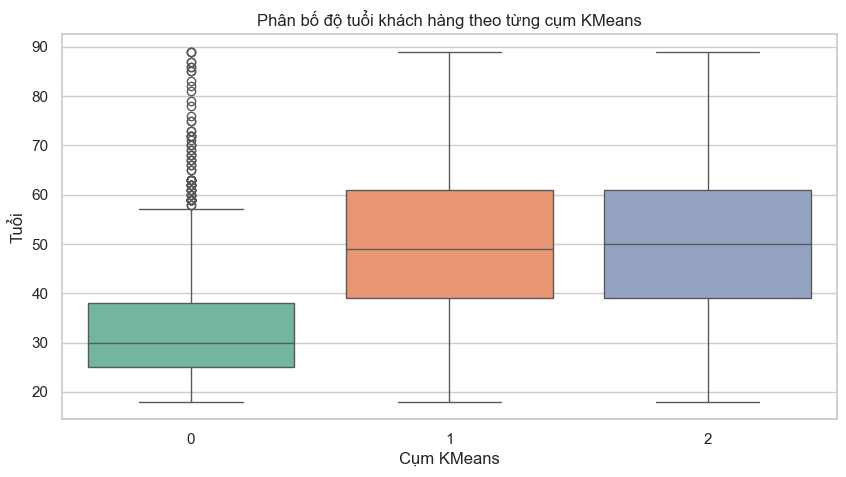

In [18]:
numerical_stats = df_train.groupby('Cluster')[['Age', 'Work_Experience', 'Family_Size']].agg(['mean', 'median'])
display(numerical_stats)

# Vẽ phân bố độ tuổi của 3 cụm
plt.figure(figsize=(10, 5))
sns.boxplot(x='Cluster', y='Age', data=df_train, hue='Cluster', palette='Set2', legend=False)
plt.title('Phân bố độ tuổi khách hàng theo từng cụm KMeans')
plt.xlabel('Cụm KMeans')
plt.ylabel('Tuổi')
plt.show()

## 3. Trực quan hóa tỷ lệ các đặc trưng nhân khẩu học theo cụm (Có gắn số liệu % cụ thể)

Chúng ta vẽ biểu đồ so sánh phân bố tỷ lệ phần trăm các đặc trưng phân loại quan trọng chéo theo cụm, hiển thị rõ số liệu tỷ lệ % trực tiếp trên cột.

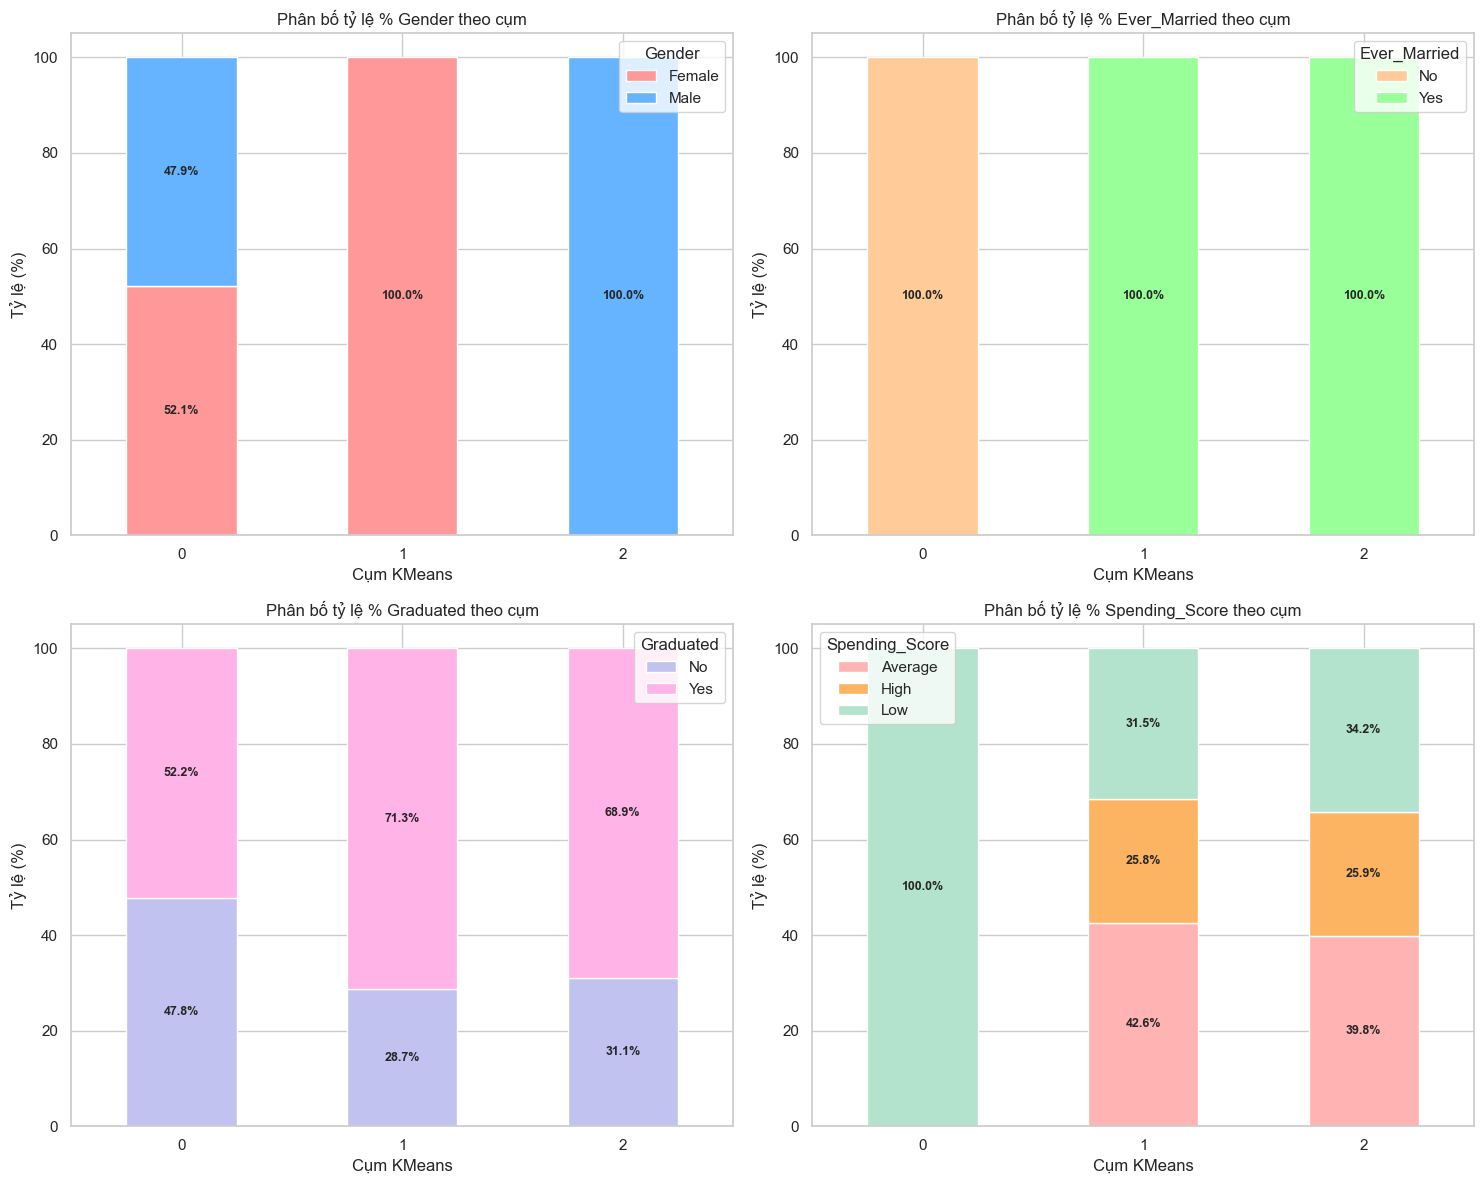

In [19]:
features = ['Gender', 'Ever_Married', 'Graduated', 'Spending_Score']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Bảng màu tùy chỉnh hài hòa
colors_dict = {
    'Gender': ['#ff9999', '#66b3ff'],
    'Ever_Married': ['#ffcc99', '#99ff99'],
    'Graduated': ['#c2c2f0', '#ffb3e6'],
    'Spending_Score': ['#ffb3b3', '#fdb462', '#b3e2cd']
}

for idx, col in enumerate(features):
    cross_dist = pd.crosstab(df_train['Cluster'], df_train[col], normalize='index') * 100
    ax = axes[idx]
    cross_dist.plot(kind='bar', stacked=True, ax=ax, color=colors_dict[col])
    ax.set_title(f'Phân bố tỷ lệ % {col} theo cụm')
    ax.set_xlabel('Cụm KMeans')
    ax.set_ylabel('Tỷ lệ (%)')
    ax.legend(title=col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # Thêm nhãn số liệu phần trăm trực tiếp trên cột
    for container in ax.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

## 4. Trực quan hóa đặc trưng nổi trội của các cụm (Có hiển thị nhãn giá trị)

Chúng ta vẽ biểu đồ so sánh sự khác biệt lớn về Nghề nghiệp (`Profession`) và Mức độ chi tiêu (`Spending_Score`) giữa các cụm khách hàng.

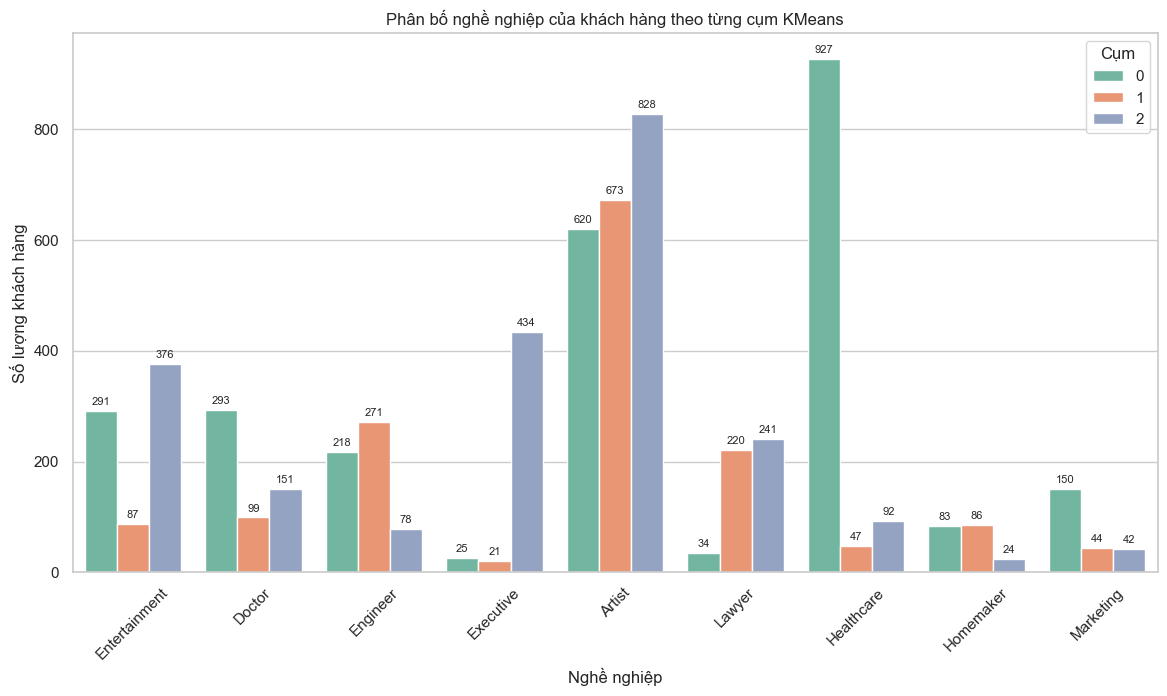

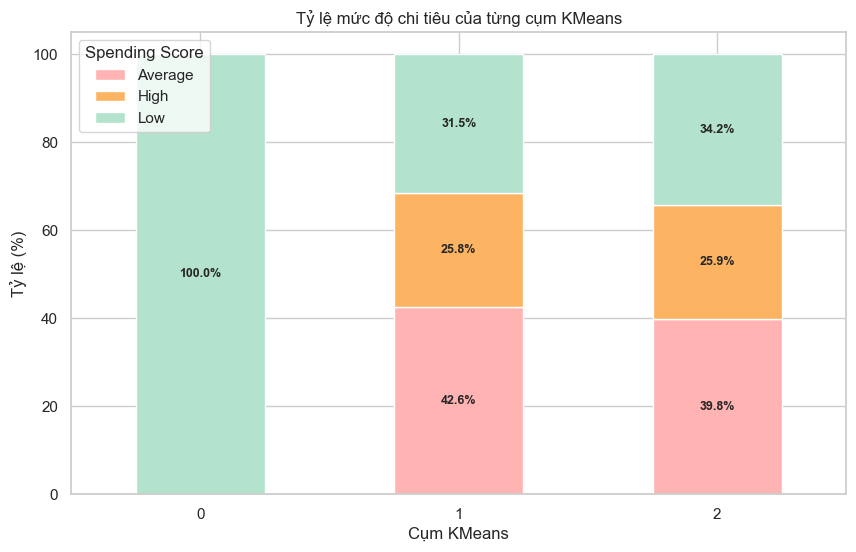

In [20]:
# 4.1. Phân bố Nghề nghiệp theo cụm
plt.figure(figsize=(14, 7))
ax1 = sns.countplot(x='Profession', hue='Cluster', data=df_train, palette='Set2')
plt.title('Phân bố nghề nghiệp của khách hàng theo từng cụm KMeans')
plt.xlabel('Nghề nghiệp')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45)
plt.legend(title='Cụm')

# Thêm nhãn số lượng mẫu trên cột
for container in ax1.containers:
    ax1.bar_label(container, fontsize=8, padding=3)
plt.show()

# 4.2. Phân bố Mức chi tiêu theo cụm
spending_dist = pd.crosstab(df_train['Cluster'], df_train['Spending_Score'], normalize='index') * 100
plt.figure(figsize=(10, 6))
ax2 = plt.gca()
spending_dist.plot(kind='bar', stacked=True, ax=ax2, color=['#ffb3b3', '#fdb462', '#b3e2cd'])
plt.title('Tỷ lệ mức độ chi tiêu của từng cụm KMeans')
plt.xlabel('Cụm KMeans')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(title='Spending Score')

# Thêm nhãn số liệu % trên cột chi tiêu
for container in ax2.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax2.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.show()

## 5. Định hình chân dung khách hàng mua ô tô (Concise Automobile Customer Personas)

* **Cụm 0: Khách hàng trẻ độc thân chi tiêu thấp**
  * **Đặc trưng**: Tuổi ~32.4 | 100% Độc thân | 100% Chi tiêu Thấp | Healthcare (35.1%), Artist (23.5%).
  * **Dòng xe mục tiêu**: Xe đô thị cỡ nhỏ (Hatchback/Sedan giá rẻ, Mini EV).
   * **Chiến lược**: Hỗ trợ vay trả góp lãi suất 0% cho người trẻ mua xe lần đầu.
   
* **Cụm 1: Phụ nữ trung niên đã kết hôn học vấn cao chi tiêu tốt**
  * **Đặc trưng**: Tuổi ~51.2 | 100% Nữ | 100% Đã kết hôn | 71.3% Tốt nghiệp | Chi tiêu Trung bình/Cao | Artist (43.5%).
  * **Dòng xe mục tiêu**: SUV gia đình cỡ trung hạng sang, xe Hybrid tiết kiệm nhiên liệu.
   * **Chiến lược**: Tập trung giới thiệu tính năng an toàn chủ động (ADAS) và không gian nội thất cao cấp.
   
* **Cụm 2: Nam giới trung niên đã kết hôn học vấn cao chi tiêu tốt**
  * **Đặc trưng**: Tuổi ~51.3 | 100% Nam | 100% Đã kết hôn | 68.9% Tốt nghiệp | Chi tiêu Trung bình/Cao | Executive (19.2%), Artist (36.5%).
  * **Dòng xe mục tiêu**: Sedan hạng sang (Executive Sedan), SUV 7 chỗ cao cấp, xe điện thể thao hiệu năng cao.
   * **Chiến lược**: Quảng bá trải nghiệm lái mạnh mẽ, công nghệ thông minh và đặc quyền dịch vụ VIP.